In [13]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
from viz_style import apply_style
apply_style()
import matplotlib.pyplot as plt

OUT = config.THRESHOLD_SWEEP_DIR

## 1. LL sweep: biased vs aligned

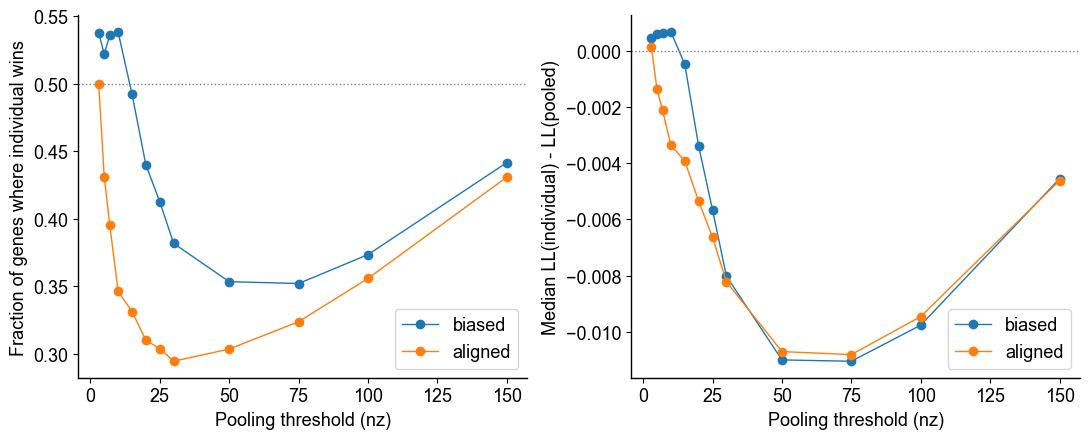

In [14]:
p_biased = OUT / "pool_vs_individual_summary.csv"
p_aligned = OUT / "pool_vs_individual_summary_aligned.csv"
if p_biased.is_file() and p_aligned.is_file():
    s_biased = pd.read_csv(p_biased)
    s_aligned = pd.read_csv(p_aligned)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].plot(s_biased["nz_threshold"], s_biased["frac_individual_wins"], "-o", label="biased")
    axes[0].plot(s_aligned["nz_threshold"], s_aligned["frac_individual_wins"], "-o", label="aligned")
    axes[0].axhline(0.5, ls=":", color="gray")
    axes[0].set(xlabel="Pooling threshold (nz)", ylabel="Fraction of genes where individual wins")
    axes[0].legend()
    axes[1].plot(s_biased["nz_threshold"], s_biased["median_ll_diff"], "-o", label="biased")
    axes[1].plot(s_aligned["nz_threshold"], s_aligned["median_ll_diff"], "-o", label="aligned")
    axes[1].axhline(0, ls=":", color="gray")
    axes[1].set(xlabel="Pooling threshold (nz)", ylabel="Median LL(individual) - LL(pooled)")
    axes[1].legend()
    fig.tight_layout()
    plt.show()
else:
    print("pending: pool_vs_individual_summary.csv / _aligned.csv not both present yet")


## 2. Individual fit-success diagnostic

,nz_bin,mean_fold_ok_rate,frac_all5_ok,n_genes
0,"[0, 3)",0.612364,0.494545,275
1,"[3, 5)",0.385135,0.121622,148
2,"[5, 7)",0.442647,0.080882,136
3,"[7, 10)",0.522807,0.127193,228
4,"[10, 15)",0.683871,0.272727,341
5,"[15, 20)",0.797554,0.458716,327
6,"[20, 30)",0.900567,0.657845,529
7,"[30, 50)",0.959906,0.853774,848
8,"[50, 75)",0.991599,0.974329,857
9,"[75, 100)",0.996830,0.989914,694


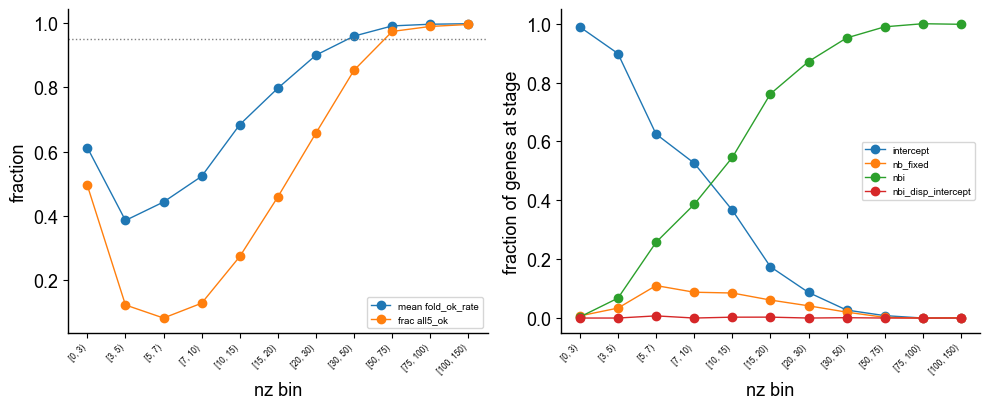

In [15]:
p_fit = OUT / "individual_fit_success.csv"
if p_fit.is_file():
    from MixedEffectsModeling.spike_in_power_test import NZ_BINS  # single source for bin edges
    diag = pd.read_csv(p_fit)
    diag["nz_bin"] = pd.cut(diag["nz"], bins=NZ_BINS + [max(diag["nz"].max() + 1, NZ_BINS[-1] + 1)], right=False)
    binned = diag.groupby("nz_bin", observed=True).agg(
        mean_fold_ok_rate=("fold_ok_rate", "mean"), frac_all5_ok=("all5_ok", "mean"),
        n_genes=("gene", "size")).reset_index()
    display(binned)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))
    x = np.arange(len(binned))
    ax1.plot(x, binned["mean_fold_ok_rate"], "-o", label="mean fold_ok_rate")
    ax1.plot(x, binned["frac_all5_ok"], "-o", label="frac all5_ok")
    ax1.axhline(0.95, ls=":", color="gray")
    ax1.set_xticks(x); ax1.set_xticklabels([str(b) for b in binned["nz_bin"]], rotation=45, ha="right", fontsize=6)
    ax1.set(xlabel="nz bin", ylabel="fraction"); ax1.legend(fontsize=7)

    stage_frac = diag.groupby("nz_bin", observed=True)["stage"].value_counts(normalize=True).unstack(fill_value=0)
    stage_frac = stage_frac.reindex(binned["nz_bin"])
    for stage in stage_frac.columns:
        ax2.plot(x, stage_frac[stage].values, "-o", label=stage)
    ax2.set_xticks(x); ax2.set_xticklabels([str(b) for b in binned["nz_bin"]], rotation=45, ha="right", fontsize=6)
    ax2.set(xlabel="nz bin", ylabel="fraction of genes at stage"); ax2.legend(fontsize=7)
    fig.tight_layout()
    plt.show()
else:
    print("pending: individual_fit_success.csv not present yet")


## 3. PPC / Z-calibration: biased vs aligned

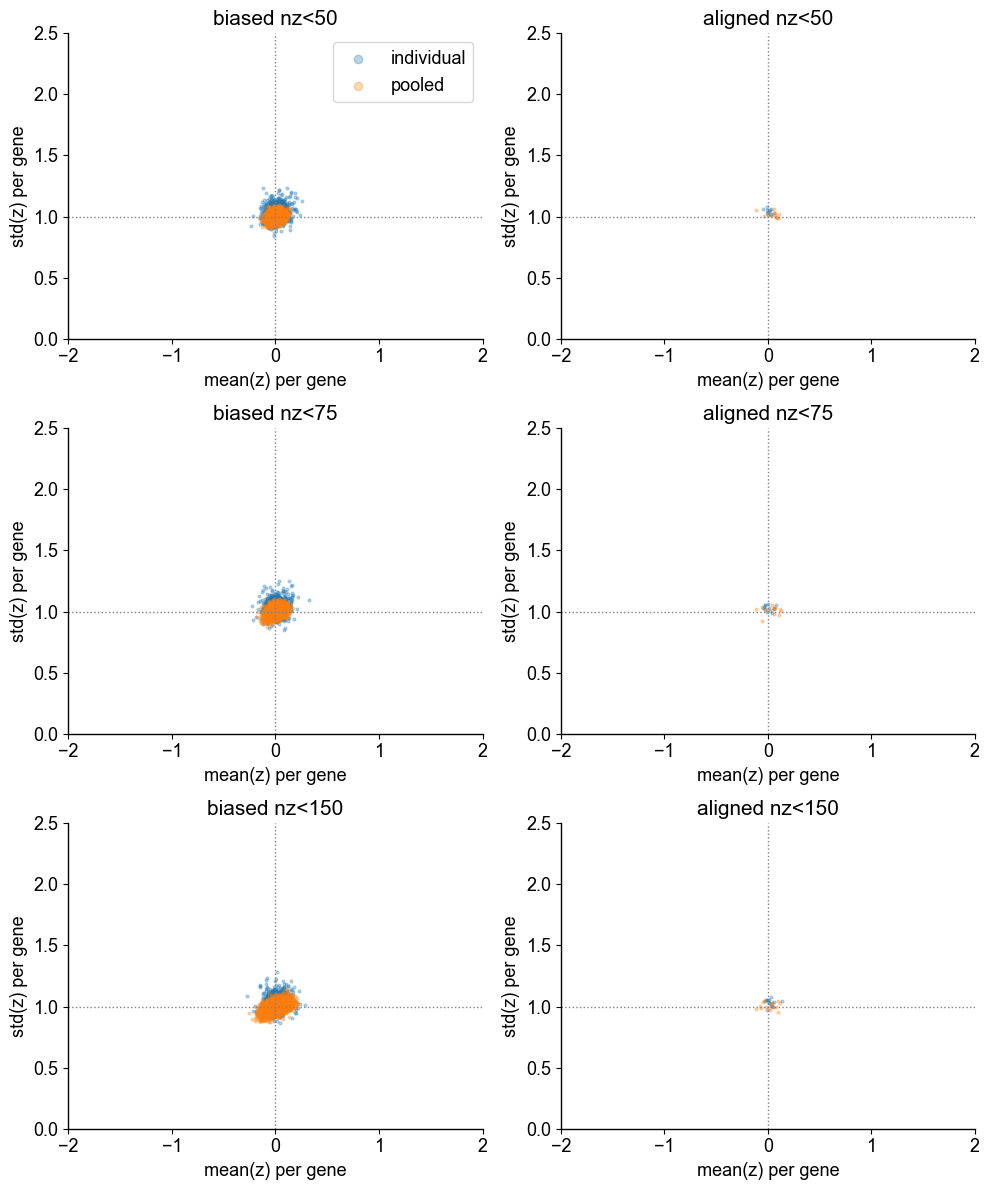

In [16]:
p_diag = OUT / "gene_level_diagnostics.csv"
p_diag_aligned = OUT / "gene_level_diagnostics_aligned.csv"
sources = [("biased", p_diag), ("aligned", p_diag_aligned)]
sources = [(name, p) for name, p in sources if p.is_file()]
if sources:
    thresholds = sorted(set().union(*[set(pd.read_csv(p)["nz_threshold"].unique()) for _, p in sources]))
    fig, axes = plt.subplots(len(thresholds), len(sources), figsize=(5 * len(sources), 4 * len(thresholds)), squeeze=False)
    colors = {"individual": "tab:blue", "pooled": "tab:orange"}
    for ci, (name, p) in enumerate(sources):
        df = pd.read_csv(p)
        for ri, T in enumerate(thresholds):
            ax = axes[ri][ci]
            sub = df[df.nz_threshold == T]
            for fit_name, c in colors.items():
                s = sub[sub.fit == fit_name]
                ax.scatter(s.mean_z, s.std_z, s=4, alpha=0.3, color=c, label=fit_name)
            ax.axvline(0, ls=":", color="gray"); ax.axhline(1, ls=":", color="gray")
            ax.set_xlim(-2, 2); ax.set_ylim(0, 2.5)
            ax.set(xlabel="mean(z) per gene", ylabel="std(z) per gene", title=f"{name} nz<{T}")
    axes[0][0].legend(markerscale=3)
    fig.tight_layout()
    plt.show()
else:
    print("pending: neither gene_level_diagnostics.csv nor _aligned.csv present yet")


## 4. Spike-in power test

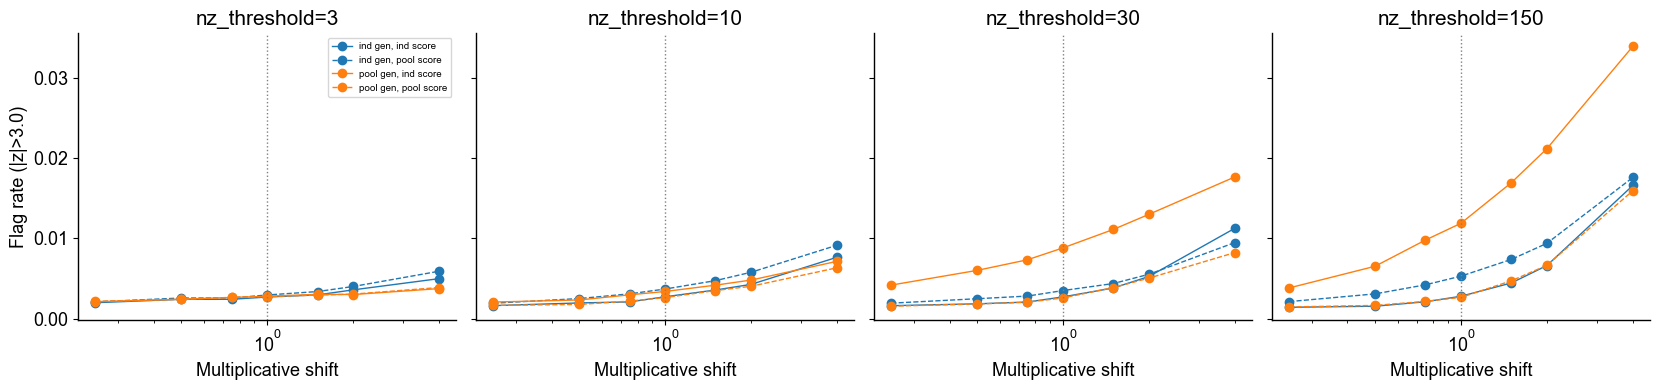

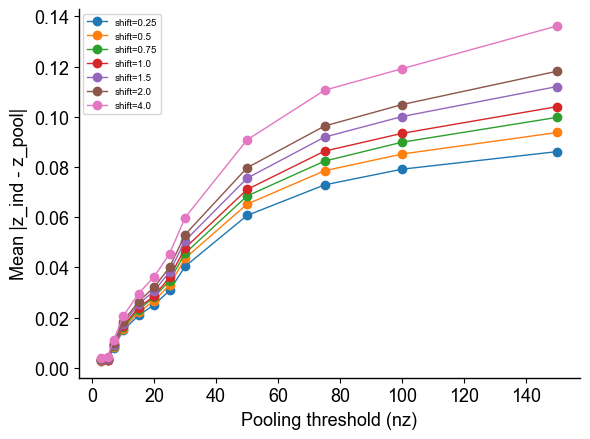

In [17]:
p_spike = OUT / "spike_in_summary.csv"
FLAG = 3.0
if p_spike.is_file():
    summary = pd.read_csv(p_spike)
    thresholds = sorted(summary["nz_threshold"].unique())
    rep_ts = thresholds
    if len(rep_ts) > 4:
        idx = np.linspace(0, len(rep_ts) - 1, 4).astype(int)
        rep_ts = [rep_ts[i] for i in idx]

    fig, axes = plt.subplots(1, len(rep_ts), figsize=(4.2 * len(rep_ts), 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, T in zip(axes, rep_ts):
        sub = summary[summary["nz_threshold"] == T]
        for generator, color in (("ind", "tab:blue"), ("pool", "tab:orange")):
            for score_col, ls, label in (("mean_flag_ind", "-", f"{generator} gen, ind score"),
                                          ("mean_flag_pool", "--", f"{generator} gen, pool score")):
                s = sub[sub["generator"] == generator]
                ax.plot(s["shift"], s[score_col], ls, color=color, marker="o", label=label)
        ax.axvline(1.0, ls=":", color="gray")
        ax.set_xscale("log")
        ax.set(xlabel="Multiplicative shift", title=f"nz_threshold={T}")
    axes[0].set_ylabel(f"Flag rate (|z|>{FLAG})")
    axes[0].legend(fontsize=7)
    fig.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(6, 4.5))
    for shift in sorted(summary["shift"].unique()):
        s = summary[summary["shift"] == shift].groupby("nz_threshold")["mean_divergence"].mean().reset_index()
        ax2.plot(s["nz_threshold"], s["mean_divergence"], "-o", label=f"shift={shift}")
    ax2.set(xlabel="Pooling threshold (nz)", ylabel="Mean |z_ind - z_pool|")
    ax2.legend(fontsize=7)
    fig2.tight_layout()
    plt.show()
else:
    print("pending: spike_in_summary.csv not present yet")


## 5. Summary numbers

In [18]:
rows = []

if p_fit.is_file():
    cross = binned[binned["mean_fold_ok_rate"] >= 0.95]
    first_cross = cross["nz_bin"].iloc[0] if len(cross) else None
    rows.append(("fold_ok_rate first >=0.95 at nz bin", first_cross))

if p_biased.is_file():
    rows.append(("biased frac_individual_wins range", (s_biased["frac_individual_wins"].min(), s_biased["frac_individual_wins"].max())))
if p_aligned.is_file():
    rows.append(("aligned frac_individual_wins range", (s_aligned["frac_individual_wins"].min(), s_aligned["frac_individual_wins"].max())))

if p_spike.is_file():
    crossover = summary[(summary["generator"] == "ind") & (np.isclose(summary["shift"], 1.0))]
    if len(crossover):
        rows.append(("spike-in FPR (ind gen, shift=1.0) mean_flag_ind range over nz",
                     (crossover["mean_flag_ind"].min(), crossover["mean_flag_ind"].max())))

pd.DataFrame(rows, columns=["metric", "value"])


,metric,value
0,fold_ok_rate first >=0.95 at nz bin,"[30, 50)"
1,biased frac_individual_wins range,"(0.352, 0.5382215288611545)"
2,aligned frac_individual_wins range,"(0.2944444444444444, 0.5)"
3,"spike-in FPR (ind gen, shift=1.0) mean_flag_in...","(0.0025433560072634, 0.0029220580851231)"
